# Week 9 — Clustering

This notebook covers the fifth project milestone:
- Apply **PCA** (from MiniLearn) to reduce 194 features to 50 principal components
- Run **KMeans** (k-means++ init) for k=8 to match the emotion count
- **Elbow plot** — inertia vs k to validate cluster count
- **Silhouette score** to measure cluster cohesion
- **Cluster-to-emotion alignment** — compare cluster assignments to true labels
- **2-D scatter** — visualise clusters in PC1/PC2 space

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler
from minilearn.decomposition import PCA
from minilearn.cluster import KMeans
from minilearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

## 1. Load and Scale Features

In [2]:
df = pd.read_csv('../outputs/features.csv')
LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_raw = df[feature_cols].values
y     = df['emotion'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'Scaled feature matrix: {X_scaled.shape}')

Scaled feature matrix: (2452, 194)


## 2. PCA Dimensionality Reduction

We reduce 194 → 50 components, retaining the majority of variance while making
KMeans faster and less susceptible to the curse of dimensionality.

Variance retained by 50 components: 86.3%


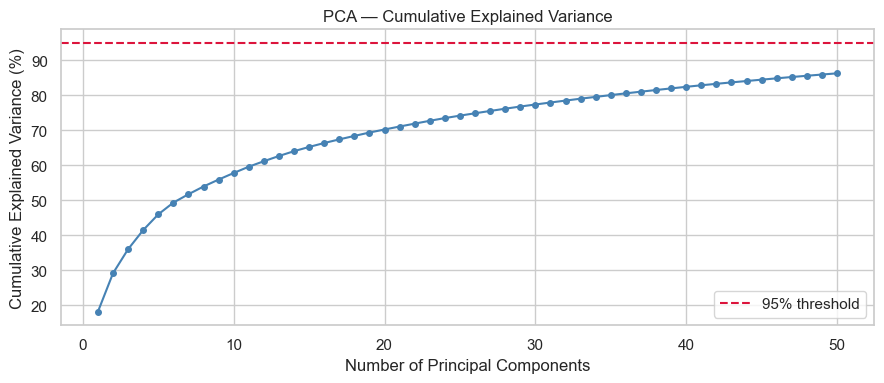

Saved to outputs/pca_variance.png


In [3]:
N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f'Variance retained by {N_COMPONENTS} components: {cumvar[-1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_COMPONENTS + 1), cumvar * 100, 'o-', markersize=4, color='steelblue')
ax.axhline(95, linestyle='--', color='crimson', label='95% threshold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/pca_variance.png')

## 3. Elbow Plot — Choose k

k= 2  inertia=344,068


k= 3  inertia=303,467


k= 4  inertia=272,033


k= 5  inertia=259,038


k= 6  inertia=249,669


...

k=10  inertia=231,862


k=11  inertia=229,442


k=12  inertia=225,062


k=13  inertia=222,705


k=14  inertia=218,673


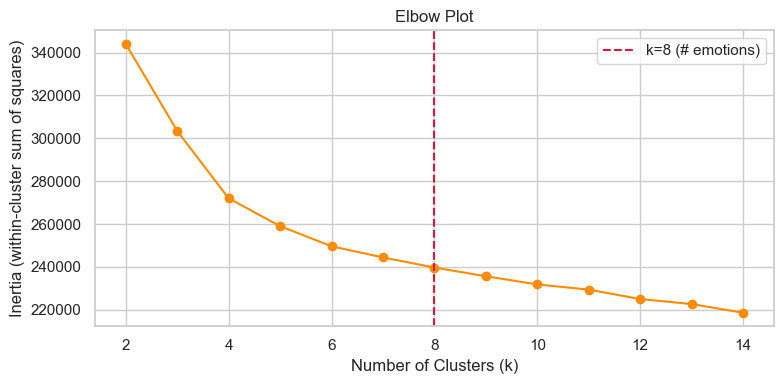

Saved to outputs/kmeans_elbow.png


In [4]:
k_range = range(2, 15)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    print(f'k={k:2d}  inertia={km.inertia_:,.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, 'o-', color='darkorange')
ax.axvline(8, linestyle='--', color='crimson', label='k=8 (# emotions)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Plot')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/kmeans_elbow.png')

## 4. Fit KMeans with k=8

In [5]:
km8 = KMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE)
cluster_labels = km8.fit_predict(X_pca)

sil = silhouette_score(X_pca, cluster_labels)
print(f'KMeans k=8  inertia={km8.inertia_:,.0f}  silhouette={sil:.3f}')

KMeans k=8  inertia=239,746  silhouette=0.133


## 5. Cluster-to-Emotion Alignment

Since KMeans assigns arbitrary cluster IDs, we look at the dominant emotion in each
cluster to understand how well the unsupervised grouping matches ground-truth labels.

In [6]:
align_df = pd.DataFrame({'cluster': cluster_labels, 'emotion': y})

# contingency table: rows=cluster, cols=emotion
contingency = (
    align_df.groupby(['cluster', 'emotion'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=EMOTION_ORDER, fill_value=0)
)

contingency['dominant_emotion'] = contingency.idxmax(axis=1)
contingency['purity'] = contingency[EMOTION_ORDER].max(axis=1) / contingency[EMOTION_ORDER].sum(axis=1)

print(contingency[['dominant_emotion', 'purity']].to_string())
print(f'\nMean cluster purity: {contingency["purity"].mean():.3f}')

emotion dominant_emotion    purity
cluster                           
0                  angry  0.180769
1                   calm  0.194260
2                   calm  0.246479
3                   calm  0.279693
4                  angry  0.231511
5                fearful  0.342105
6                    sad  0.208556
7                   calm  0.189723

Mean cluster purity: 0.234


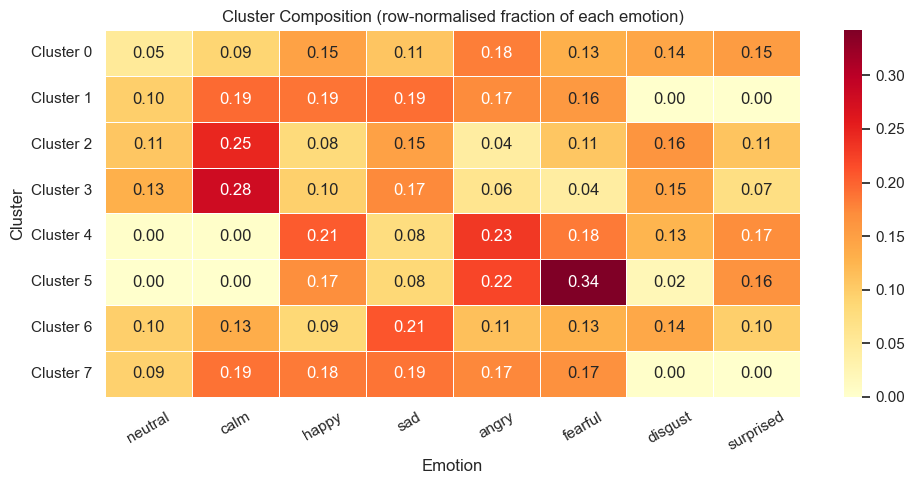

Saved to outputs/cluster_composition.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ct_norm = contingency[EMOTION_ORDER].div(contingency[EMOTION_ORDER].sum(axis=1), axis=0)
sns.heatmap(
    ct_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=EMOTION_ORDER, yticklabels=[f'Cluster {i}' for i in range(8)],
    ax=ax, linewidths=0.4
)
ax.set_title('Cluster Composition (row-normalised fraction of each emotion)')
ax.set_xlabel('Emotion')
ax.set_ylabel('Cluster')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../outputs/cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/cluster_composition.png')

## 6. 2-D Cluster Scatter (PC1 vs PC2)

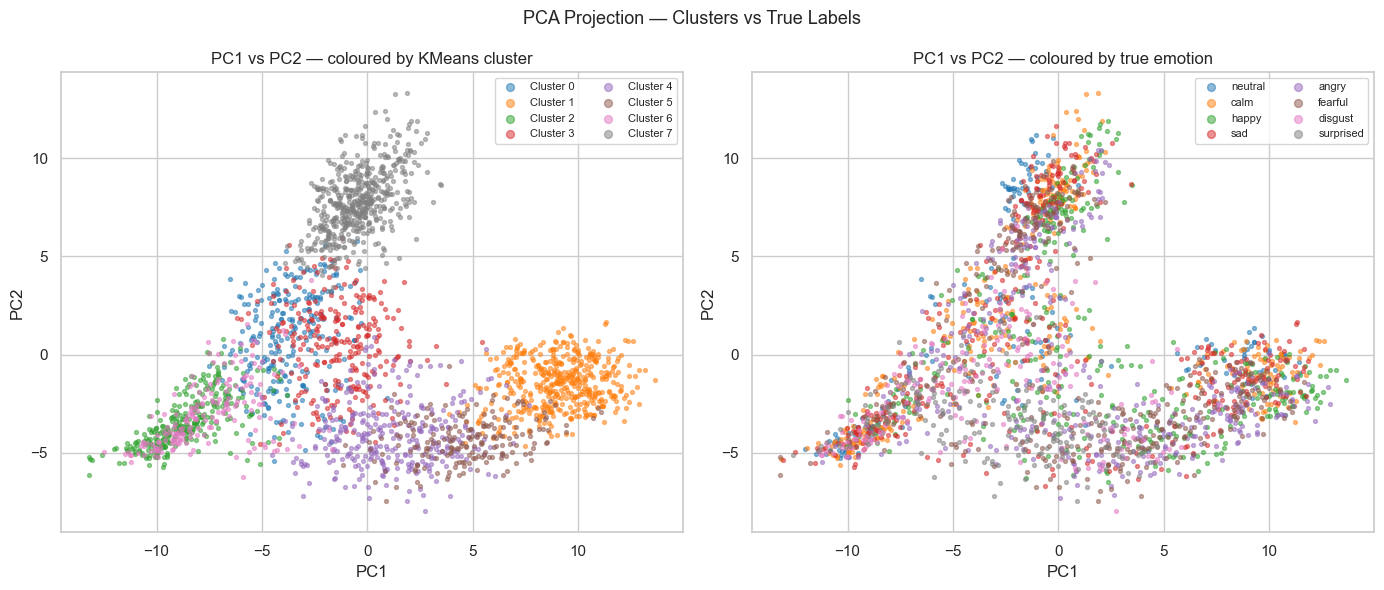

Saved to outputs/cluster_scatter.png


In [8]:
palette = sns.color_palette('tab10', 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: colour by cluster
for k in range(8):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.5,
                    color=palette[k], label=f'Cluster {k}')
axes[0].set_title('PC1 vs PC2 — coloured by KMeans cluster')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=8, ncol=2)

# Right: colour by true emotion
emotion_palette = dict(zip(EMOTION_ORDER, sns.color_palette('tab10', 8)))
for em in EMOTION_ORDER:
    mask = y == em
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.5,
                    color=emotion_palette[em], label=em)
axes[1].set_title('PC1 vs PC2 — coloured by true emotion')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=2, fontsize=8, ncol=2)

plt.suptitle('PCA Projection — Clusters vs True Labels', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/cluster_scatter.png')

## 7. Summary

In [9]:
print('=== Clustering Summary ===')
print(f'PCA variance retained ({N_COMPONENTS} components): {cumvar[-1]*100:.1f}%')
print(f'KMeans k=8  inertia        : {km8.inertia_:,.0f}')
print(f'Silhouette score           : {sil:.3f}  (range -1 to 1, higher = better)')
print(f'Mean cluster purity        : {contingency["purity"].mean():.3f}')
print()
print('Cluster → dominant emotion:')
for i, row in contingency.iterrows():
    print(f'  Cluster {i}: {row["dominant_emotion"]:10s}  purity={row["purity"]:.2f}')

=== Clustering Summary ===
PCA variance retained (50 components): 86.3%
KMeans k=8  inertia        : 239,746
Silhouette score           : 0.133  (range -1 to 1, higher = better)
Mean cluster purity        : 0.234

Cluster → dominant emotion:
  Cluster 0: angry       purity=0.18
  Cluster 1: calm        purity=0.19
  Cluster 2: calm        purity=0.25
  Cluster 3: calm        purity=0.28
  Cluster 4: angry       purity=0.23
  Cluster 5: fearful     purity=0.34
  Cluster 6: sad         purity=0.21
  Cluster 7: calm        purity=0.19
